# Autospectrum

We want to compute a one-sided autospectrum, $S(f)$, as a function for input time series, $x(t)$, 

The autospectrum is the fourier transform of the autocorrelation function, $R(\tau)$, of the time series. The autocorrelation function is defined as:

In [1]:
import numpy as np
from scipy import signal
from scipy.stats import chi2

def auto_spc(x, dt, Navg, r_win):
    """
    Computes a one-sided autospectrum S as a function for input time
    series x, with a sample period of dt. Smooths Sxx over Navg
    frequencies. A Tukey window is applied prior to taking the fft.
    r_win is the cosine fraction of the window (0 = boxcar, 0.5 = Hann window).
    
    Parameters:
    x      : array_like, time series
    dt     : float, sample period
    Navg   : int, no. of frequency bands to smooth
    r_win  : float, cosine fraction of the Tukey window
    
    Returns:
    S      : ndarray, autospectrum
    Su     : ndarray, 95% confidence level upper
    Sl     : ndarray, 95% confidence level lower
    f      : ndarray, frequency
    """
    # Ensure x is a 1D numpy array
    x = np.asarray(x).flatten()
    N = len(x)
    
    # record length is even
    if N % 2 != 0:
        x = x[:-1]
        N -= 1
        
    # remove mean
    x_rm = x - np.mean(x)
    
    # Window and compute FFT
    w = signal.windows.tukey(N, alpha=r_win)
    X = np.fft.fft(x_rm * w)
    
    # One-sided frequency 
    # skipping 0 (DC component), going up to N/2
    f = np.arange(1, int(N/2) + 1) / (N * dt)
    
    # Compute spectral density
    # Index 1 corresponds to 1/(N*dt), index int(N/2) to 1/(2*dt)
    S = np.abs(X[1:int(N/2)+1])**2 / N * dt
    
    # Double to account for negative frequencies, except Nyquist (the last element)
    S[:-1] = 2 * S[:-1]
    
    # Correct for window assuming total variance is conserved 
    varx = np.var(x_rm, ddof=1)
    varS = np.sum(S) / (N * dt)
    S = S * varx / varS
    
    # Running mean, discard trims the ends of the record
    kernel = np.ones(Navg) / Navg # small matrix to apply effects (blurring, sharpening, etc...)
    S = np.convolve(S, kernel, mode='valid') # apply ketnel to data 
    f = np.convolve(f, kernel, mode='valid')
    
    # Compute 95% confidence interval
    nu = 2 * Navg
    alpha = 0.05    
    Su = S * nu / chi2.ppf(alpha / 2, nu)
    Sl = S * nu / chi2.ppf(1 - alpha / 2, nu)
    
    return S, Su, Sl, f

#### Testing script with fake data

/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_23961/2651577661.py:43: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0, 150]) # limit X-axis to 150 Hz to clearly see our 20 Hz and 80 Hz peaks


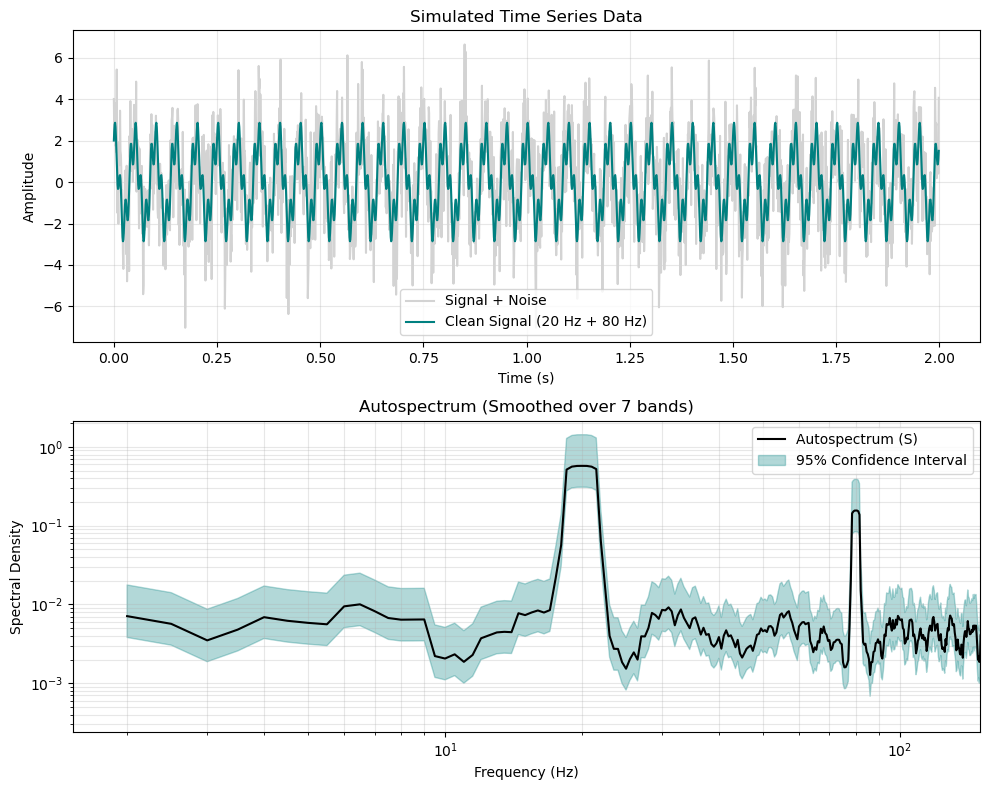

In [11]:
import matplotlib.pyplot as plt

fs = 1000.0              # Sample rate in Hz
dt = 1.0 / fs            # Sample period
t = np.arange(0, 2.0, dt) # 2 seconds of data

# Create a clean signal with a 20 Hz and an 80 Hz component
freq1, freq2 = 20.0, 80.0
clean_signal = 2.0 * np.cos(2 * np.pi * freq1 * t) + 1.0 * np.sin(2 * np.pi * freq2 * t)

# Add Gaussian noise
noise = np.random.normal(0, 1.5, len(t))
x = clean_signal + noise

# run autospec
Navg = 7      # Smooth over 7 frequency bands
r_win = 0.5   # Hann window
S, Su, Sl, f = auto_spc(x, dt, Navg, r_win)


# --- 4. Plot the Results ---
plt.figure(figsize=(10, 8))

# time series
plt.subplot(2, 1, 1)
plt.plot(t, x, label='Signal + Noise', color='lightgray')
plt.plot(t, clean_signal, label='Clean Signal (20 Hz + 80 Hz)', color='teal', linewidth=1.5)
plt.title('Simulated Time Series Data')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)

# autospec
plt.subplot(2, 1, 2)
plt.loglog(f, S, label='Autospectrum (S)', color='black', linewidth=1.5)
# Fill the area between the upper and lower confidence limits
plt.fill_between(f, Sl, Su, color='teal', alpha=0.3, label='95% Confidence Interval')

plt.title(f'Autospectrum (Smoothed over {Navg} bands)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Spectral Density')
plt.xlim([0, 150]) # limit X-axis to 150 Hz to clearly see our 20 Hz and 80 Hz peaks
plt.legend()
plt.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

#### testing with real data

In [3]:
from scipy.io import loadmat
import pandas as pd
import xarray as xr

# load and unpack the data
mat = loadmat('data/CMI_data.mat')
cmi_data = mat['CMI'][0, 0]

# convert the5400x200 time matrix from datenum to datetime objects
t_flat = cmi_data['t'].flatten()
times_2d = pd.to_datetime(t_flat - 719529, unit='D').values.reshape(5400, 200)

# build the Dataset
ds = xr.Dataset(
    data_vars={
        var: (["row", "col"], cmi_data[var]) 
        for var in ['p2', 'p3', 'p4', 'p6', 'p7', 'e7']
    },
    coords={
        "time": (["row", "col"], times_2d),
        "row": np.arange(5400),
        "col": np.arange(200),
    }
)


In [4]:
def compute_hs(dataset, variable_name, fs, fmin, fmax):
    """
    Computes significant wave height (Hs) across all bursts simultaneously.
    Returns a 1D array of Hs values (length 200).
    """
    # 1. Extract the 2D time series (rows=time, cols=bursts)
    x = dataset[variable_name].values
    
    # 2. Define dimensions (N = 5400 samples)
    N = x.shape[0]
    df = fs / N

    # 3. Compute the FFT along the time axis (axis=0)
    fft = np.fft.fft(x, axis=0)

    # 4. Isolate the positive frequencies
    freqs = np.fft.fftfreq(N, d=1/fs)
    pos_idx = freqs > 0
    freqs_pos = freqs[pos_idx]
    
    # Subset the 2D FFT array for positive frequencies
    fft_pos = fft[pos_idx, :]

    # 5. Calculate energy spectrum 
    S = (2 / (N * fs)) * np.abs(fft_pos)**2

    # 6. Create a mask for the specified frequency band
    mask = (freqs_pos >= fmin) & (freqs_pos <= fmax)
    
    # Apply the mask to the rows (frequencies)
    S_band = S[mask, :]

    # 7. Compute variance (m0) by summing along the frequency axis (axis=0)
    m0 = np.sum(S_band * df, axis=0)

    # 8. Compute Hs for all 200 bursts
    Hs = 4 * np.sqrt(m0)

    return Hs

In [5]:
fs = 1.0          # 1 Hz sampling rate from 1-second measurements [cite: 26]
ss_fmin = 1/25    # Lower limit for SS band 
ss_fmax = 0.5

hs_ss_e7 = compute_hs(ds, 'e7', fs, ss_fmin, ss_fmax)

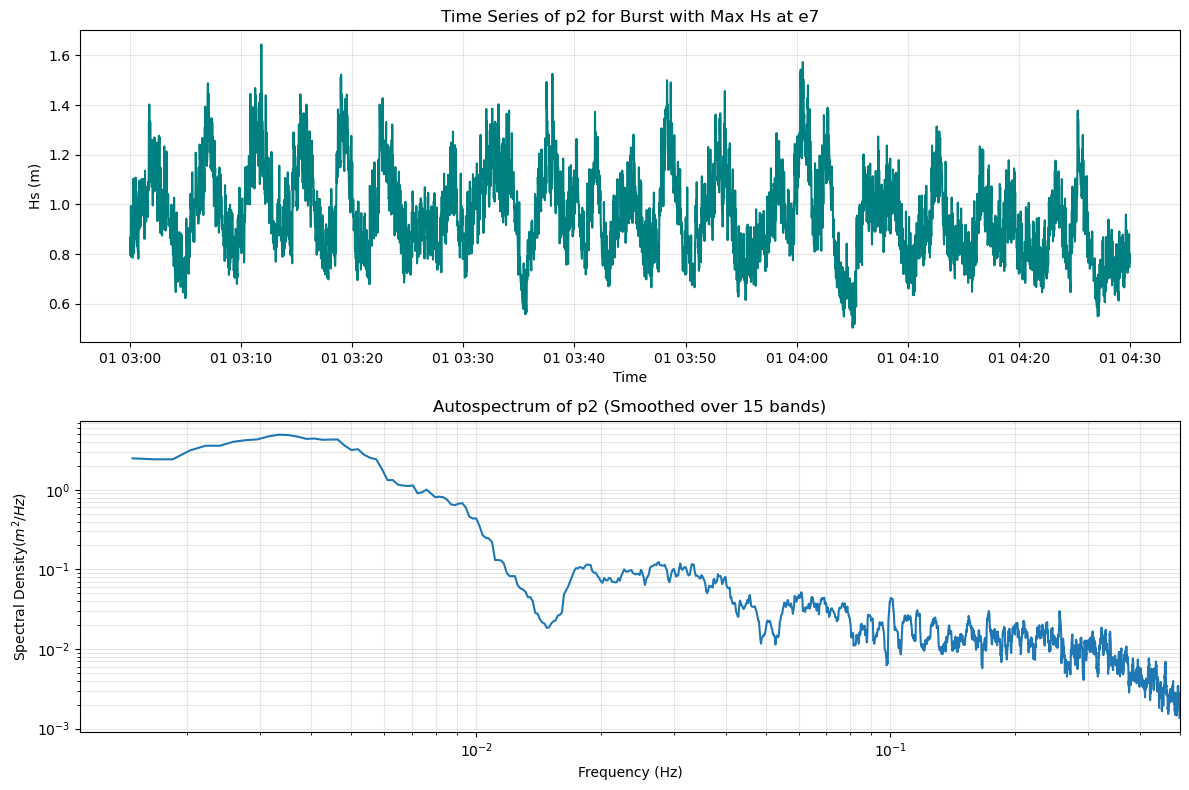

In [6]:
imax_hs7 = np.argmax(hs_ss_e7) # index of burst w max Hss at e7

# use .isel to extract time series for burst with max Hss at e7 for p1
p2_burst = ds['p2'].isel(col=imax_hs7).values

# run autospec on this burst
dt = 1.0 / fs
Navg = 15 # smooth over 15 bands
r_win = 0.5 # hann window
S_p2, Su_p2, Sl_p2, f_p2 = auto_spc(p2_burst, dt, Navg, r_win)

# plot the result
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(12,8))

# time series
ax1.plot(ds['time'][:, imax_hs7], p2_burst, color='teal')
ax1.set_title('Time Series of p2 for Burst with Max Hs at e7')
ax1.set_xlabel('Time')
ax1.set_ylabel('Hs (m)')
ax1.grid(True, alpha=0.3)

# autospec
ax2.loglog(f_p2, S_p2)
ax2.set_title(f'Autospectrum of p2 (Smoothed over {Navg} bands)')
ax2.grid(True, alpha=0.3, which="both")
ax2.set_xlim([None, fs/2]) # limit X-axis to Nyquist frequency
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Spectral Density($m^2/Hz$)')

plt.tight_layout()

In [9]:
1/(10**-1.9)

79.43282347242813